# NYC Taxi Demand Forecasting: Exploratory Data Analysis
This notebook explores January 2025 NYC yellow taxi trip data and prepares the foundation for building an hourly taxy demand forecasting model.
The main goal is to understand the raw data, identify useful features, check for data quality issues, and create the target variable: hourly pickup demand by taxi zone

## 1. Observations

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_parquet("../data/raw/yellow_tripdata_2025-01.parquet")
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")

'df' has the actual taxi trip records, where each row is one taxi ride. 'zones' is a lookup table that translates IDs into readable borough and zone names.

In [33]:
print(df.shape)
df.head()

(3475226, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [34]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

## 2. Zone Lookup Table
The taxi trip dataset uses numeric zone IDs. The zone lookup table helps translate the IDs into borough and zone names.

In [35]:
print(zones.shape)
zones.head()

(265, 4)


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


## 3. Date Range

In [36]:
start_date = df["tpep_pickup_datetime"].min()
end_date = df["tpep_pickup_datetime"].max()

start_date, end_date

(Timestamp('2024-12-31 20:47:55'), Timestamp('2025-02-01 00:00:44'))

It is important to know the date range because the model can only learn patterns that exist in the data, so if we only use one month, the model can learn hourly and weekly patterns, but it won't be able to learn yearly seasonality.

## 4. Missing Values

In [37]:
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

In [38]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

passenger_count          15.542845
congestion_surcharge     15.542845
store_and_fwd_flag       15.542845
RatecodeID               15.542845
Airport_fee              15.542845
tpep_dropoff_datetime     0.000000
VendorID                  0.000000
tpep_pickup_datetime      0.000000
DOLocationID              0.000000
payment_type              0.000000
trip_distance             0.000000
PULocationID              0.000000
extra                     0.000000
fare_amount               0.000000
mta_tax                   0.000000
tip_amount                0.000000
improvement_surcharge     0.000000
tolls_amount              0.000000
total_amount              0.000000
cbd_congestion_fee        0.000000
dtype: float64

## 5. Create Basic Time Features
The full timestamp is too specific and is not directly useful for most tabular models. Features like hour and day of week help the model learn patterns like rush hour or weekend demand.

In [39]:
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
df["day_name"] = df["tpep_pickup_datetime"].dt.day_name()
df["date"] = df["tpep_pickup_datetime"].dt.date

## 6. Demand by Hour

In [40]:
trips_by_hour = df.groupby("hour").size()
trips_by_hour

hour
0      93417
1      64484
2      43929
3      28492
4      20033
5      22551
6      50026
7     102581
8     141305
9     142877
10    148316
11    160076
12    175432
13    186144
14    202289
15    213694
16    217051
17    253518
18    267951
19    221055
20    195001
21    205978
22    182214
23    136812
dtype: int64

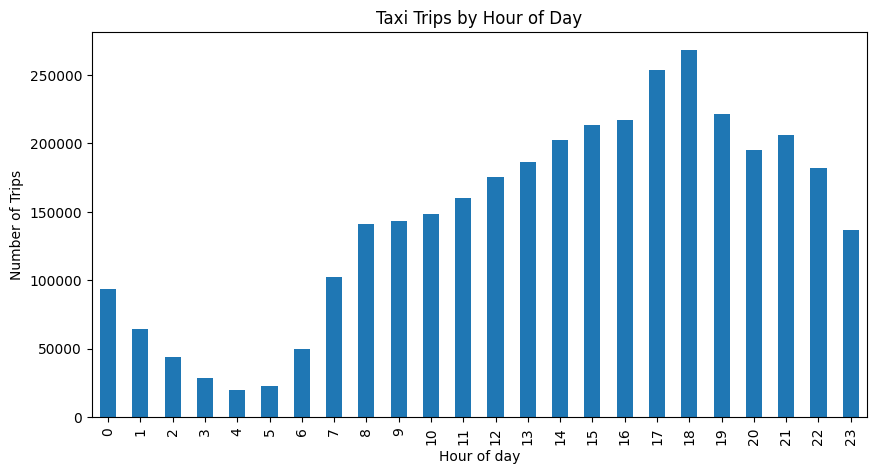

In [41]:
trips_by_hour.plot(kind="bar", figsize=(10, 5))

plt.title("Taxi Trips by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Number of Trips")
plt.show()

Taxi demand is not evenly distributed throughout the day. Demand is usually lower overnight and higher during evening hours.

## 7. Trips by Day of Week

In [42]:
trips_by_day = df.groupby("day_name").size()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

trips_by_day = trips_by_day.reindex(day_order)
trips_by_day

day_name
Monday       363772
Tuesday      453993
Wednesday    577375
Thursday     614230
Friday       586863
Saturday     476399
Sunday       402594
dtype: int64

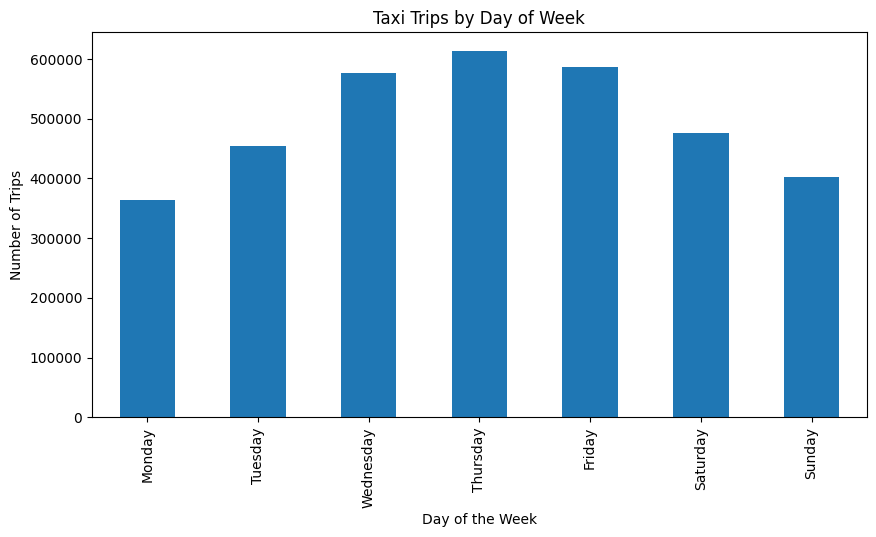

In [43]:
trips_by_day.plot(kind="bar", figsize=(10, 5))

plt.title("Taxi Trips by Day of Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Trips")
plt.show()

## 8. Top Pickup Zones

In [44]:
pickup_zone_counts = df.groupby("PULocationID").size().reset_index(name="pickups").sort_values("pickups", ascending=False)

pickup_zone_counts.head()

,PULocationID,pickups
156,161,169977
232,237,163703
231,236,155647
127,132,146137
225,230,125829


In [45]:
pickup_zone_counts_named = pickup_zone_counts.merge(
    zones,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

pickup_zone_counts_named.head()

,PULocationID,pickups,LocationID,Borough,Zone,service_zone
0,161,169977,161,Manhattan,Midtown Center,Yellow Zone
1,237,163703,237,Manhattan,Upper East Side South,Yellow Zone
2,236,155647,236,Manhattan,Upper East Side North,Yellow Zone
3,132,146137,132,Queens,JFK Airport,Airports
4,230,125829,230,Manhattan,Times Sq/Theatre District,Yellow Zone


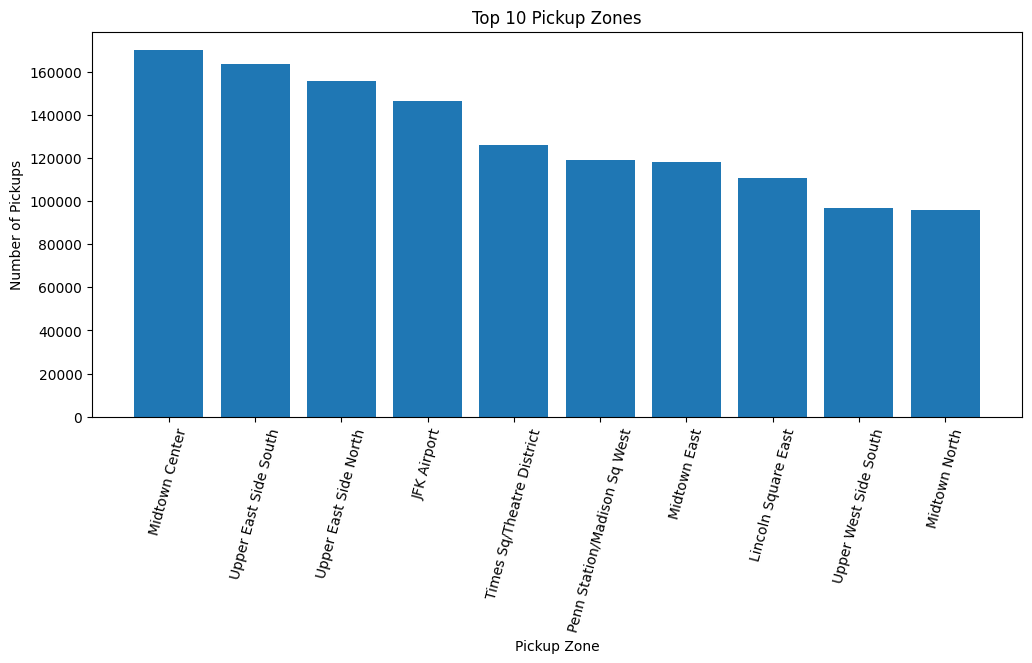

In [46]:
top_zones = pickup_zone_counts_named.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_zones["Zone"], top_zones["pickups"])
plt.title("Top 10 Pickup Zones")
plt.xlabel("Pickup Zone")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=75)
plt.show()

## 9. Basic Data Quality Checks

In [47]:
df["trip_distance"].describe()

count    3.475226e+06
mean     5.855126e+00
std      5.646016e+02
min      0.000000e+00
25%      9.800000e-01
50%      1.670000e+00
75%      3.100000e+00
max      2.764236e+05
Name: trip_distance, dtype: float64

In [48]:
df["passenger_count"].describe()

count    2.935077e+06
mean     1.297859e+00
std      7.507503e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

In [49]:
df["fare_amount"].describe()

count    3.475226e+06
mean     1.708180e+01
std      4.634729e+02
min     -9.000000e+02
25%      8.600000e+00
50%      1.211000e+01
75%      1.950000e+01
max      8.633721e+05
Name: fare_amount, dtype: float64

In [50]:
negative_distance_count = (df["trip_distance"] < 0).sum()
zero_distance_count = (df["trip_distance"] == 0).sum()
negative_fare_count = (df["fare_amount"] < 0).sum()

negative_distance_count, zero_distance_count, negative_fare_count

(np.int64(0), np.int64(90893), np.int64(144118))

## 10. Create the Forecasting Target

In [51]:
hourly_demand = (
    df.groupby([
        pd.Grouper(key="tpep_pickup_datetime", freq="h"),
        "PULocationID"
    ])
    .size()
    .reset_index(name="pickups")
)

hourly_demand.head()

,tpep_pickup_datetime,PULocationID,pickups
0,2024-12-31 20:00:00,48,1
1,2024-12-31 20:00:00,246,1
2,2024-12-31 20:00:00,249,1
3,2024-12-31 21:00:00,42,1
4,2024-12-31 21:00:00,141,1


In [52]:
hourly_demand.shape

(97033, 3)

In [53]:
hourly_demand.describe()

,tpep_pickup_datetime,PULocationID,pickups
count,97033,97033.000000,97033.000000
mean,2025-01-16 22:52:42.915709,139.422753,35.814888
min,2024-12-31 20:00:00,1.000000,1.000000
25%,2025-01-09 14:00:00,74.000000,1.000000
50%,2025-01-17 08:00:00,141.000000,4.000000
75%,2025-01-24 11:00:00,211.000000,28.000000
max,2025-02-01 00:00:00,265.000000,950.000000
std,NaN,76.238529,74.802736


## 11. Add Time Features to Hourly Demand

In [54]:
hourly_demand["hour"] = hourly_demand["tpep_pickup_datetime"].dt.hour
hourly_demand["day_of_week"] = hourly_demand["tpep_pickup_datetime"].dt.dayofweek
hourly_demand["day_name"] = hourly_demand["tpep_pickup_datetime"].dt.day_name()
hourly_demand["month"] = hourly_demand["tpep_pickup_datetime"].dt.month
hourly_demand["is_weekend"] = hourly_demand["day_of_week"].isin([5, 6])

hourly_demand.head()

,tpep_pickup_datetime,PULocationID,pickups,hour,day_of_week,day_name,month,is_weekend
0,2024-12-31 20:00:00,48,1,20,1,Tuesday,12,False
1,2024-12-31 20:00:00,246,1,20,1,Tuesday,12,False
2,2024-12-31 20:00:00,249,1,20,1,Tuesday,12,False
3,2024-12-31 21:00:00,42,1,21,1,Tuesday,12,False
4,2024-12-31 21:00:00,141,1,21,1,Tuesday,12,False


## 12. Distribution of Hourly Pickups

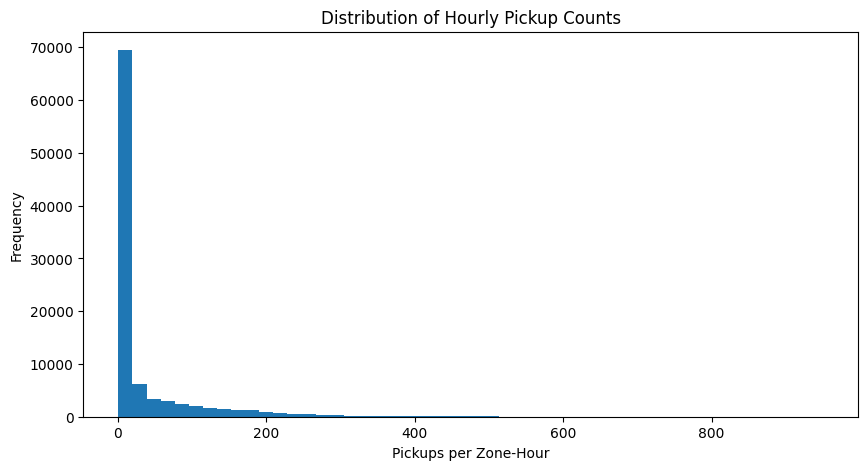

In [55]:
hourly_demand["pickups"].plot(kind="hist", bins=50, figsize=(10, 5))

plt.title("Distribution of Hourly Pickup Counts")
plt.xlabel("Pickups per Zone-Hour")
plt.ylabel("Frequency")
plt.show()

The distribution of hourly pickup counts is very right-skewed. Most zone-hour observations have few pickups, while a small number of zone-hours experience high demand. This suggests that taxi activity is concentrated in a limited number of locations and time periods instead of being evenly distributed throughout the city.

## 13. Average Demand by Hour

In [56]:
avg_pickups_by_hour = hourly_demand.groupby("hour")["pickups"].mean()

avg_pickups_by_hour

hour
0     26.797762
1     22.657765
2     18.033251
3     11.691424
4      6.384003
5      6.026456
6     10.547333
7     19.659065
8     27.049196
9     30.251323
10    33.685215
11    35.996402
12    39.193923
13    41.091391
14    43.747621
15    47.752849
16    50.535739
17    58.943967
18    64.026523
19    56.914264
20    52.055793
21    55.133298
22    46.305972
23    34.177367
Name: pickups, dtype: float64

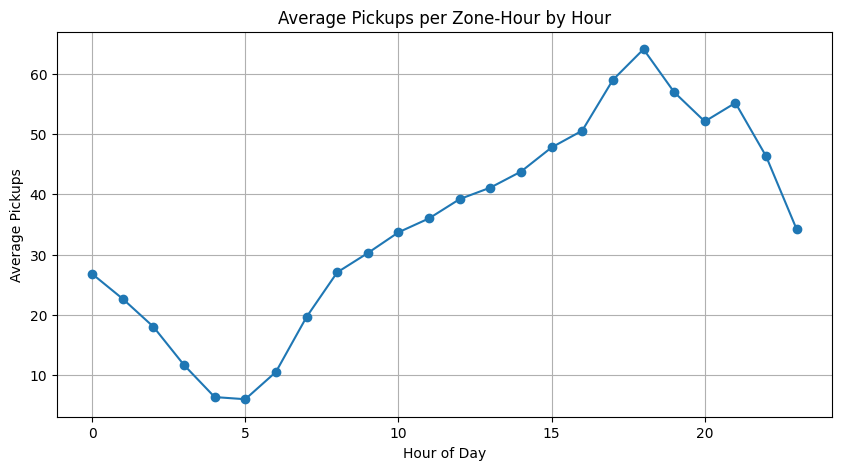

In [57]:
avg_pickups_by_hour.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Average Pickups per Zone-Hour by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Pickups")
plt.grid(True)
plt.show()

## 14. Save Processed EDA Output

In [58]:
output_path = "../data/processed/hourly_demand_2025-01.parquet"

hourly_demand.to_parquet(output_path, index=False)

In [59]:
pd.read_parquet(output_path).head()

,tpep_pickup_datetime,PULocationID,pickups,hour,day_of_week,day_name,month,is_weekend
0,2024-12-31 20:00:00,48,1,20,1,Tuesday,12,False
1,2024-12-31 20:00:00,246,1,20,1,Tuesday,12,False
2,2024-12-31 20:00:00,249,1,20,1,Tuesday,12,False
3,2024-12-31 21:00:00,42,1,21,1,Tuesday,12,False
4,2024-12-31 21:00:00,141,1,21,1,Tuesday,12,False


## Summary

In this notebook, I explored the January 2025 NYC yellow taxi trip dataset and transformed raw trip records into an hourly demand dataset.

Key takeaways:

- The raw dataset contains over 3.4 million taxi trips.
- Each raw row represents one completed taxi trip.
- The core forecasting columns are `tpep_pickup_datetime` and `PULocationID`.
- Taxi demand varies by hour, day of week, and pickup zone.
- The target variable is `pickups`, which represent the number of taxi pickups in a zone during a specific hour.
- Useful features include pickup zone, hour, day of week, month, and weekend indicator.